# ANALYSIS OF SCORES

In [1]:
from src.score import Score
from src.linear_predictor import LinearPredictor
import os
import src.constants as cn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.biomodels_iterator import BiomodelsIterator
from src.trajectory import Trajectory
from src.trajectory_collection import TrajectoryCollection
from src.multiple_linear_predictor import MultipleLinearPredictor

# Timeseries Plots

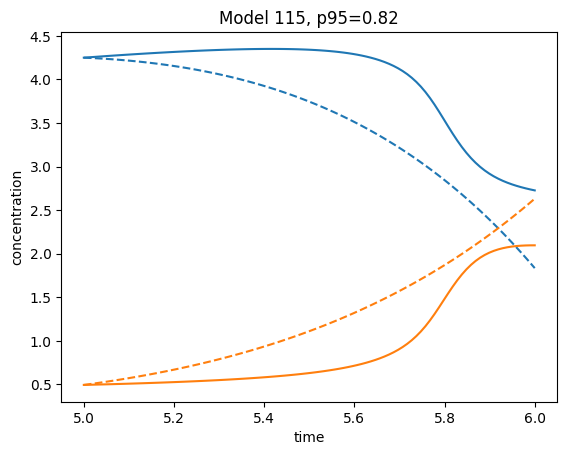

In [2]:
def plotModel(model_num, start_time=0, end_time=None, **kwargs):
    predictor = LinearPredictor.makeFromBiomodels(model_num=model_num, 
                start_time=start_time, end_time=end_time, num_step=-1, num_point=100,
                jacobian_selection=cn.JAC_FITTED)
    df = predictor.score()
    score_p95 = df.loc[0, 'p95']
    _ = predictor.plotPrediction(title=f"Model {model_num}, p95={score_p95:.2f}", **kwargs)

plotModel(115, start_time=5, end_time=6, legend=False)

Processing model: BIOMD0000000001
Error fitting Jacobian: NaN values detected in your input data or the output of your objective/model function - fitting algorithms cannot handle this! Please read https://lmfit.github.io/lmfit-py/faq.html#i-get-errors-from-nan-in-my-fit-what-can-i-do for more information.
Falling back to JAC_MEDIAN.
Error fitting Jacobian: NaN values detected in your input data or the output of your objective/model function - fitting algorithms cannot handle this! Please read https://lmfit.github.io/lmfit-py/faq.html#i-get-errors-from-nan-in-my-fit-what-can-i-do for more information.
Falling back to JAC_MEDIAN.
Processing model: BIOMD0000000002
Error fitting Jacobian: NaN values detected in your input data or the output of your objective/model function - fitting algorithms cannot handle this! Please read https://lmfit.github.io/lmfit-py/faq.html#i-get-errors-from-nan-in-my-fit-what-can-i-do for more information.
Falling back to JAC_MEDIAN.
Error fitting Jacobian: NaN v

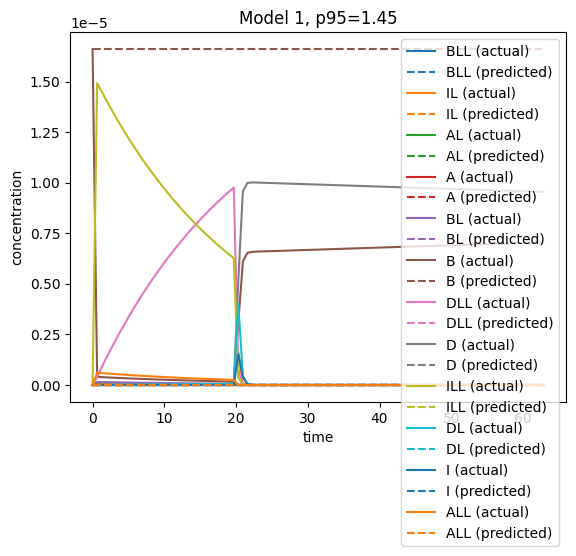

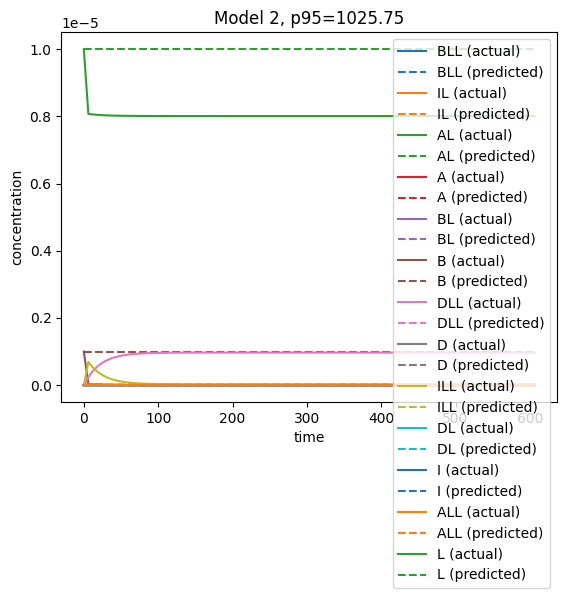

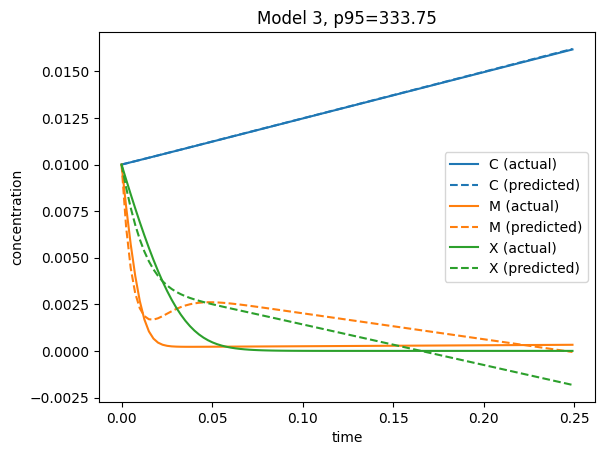

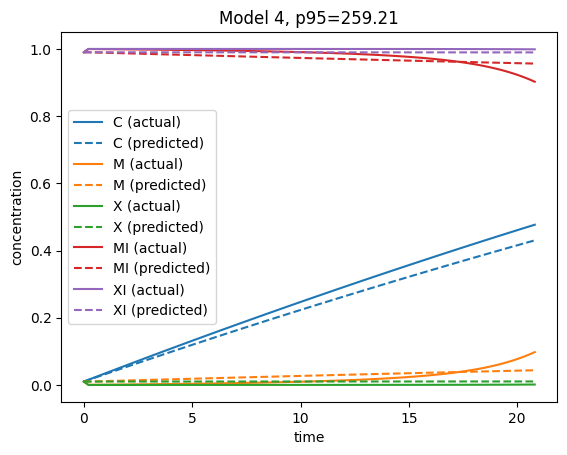

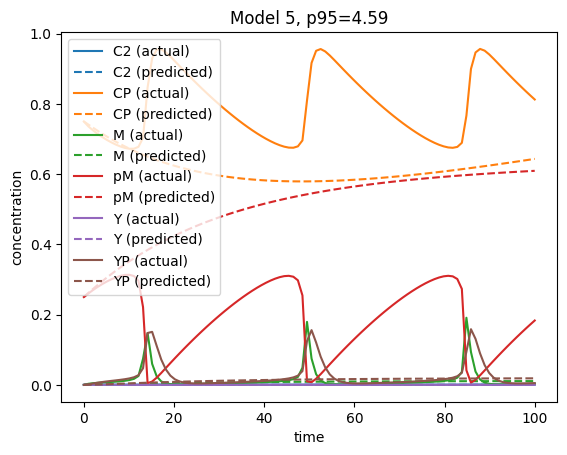

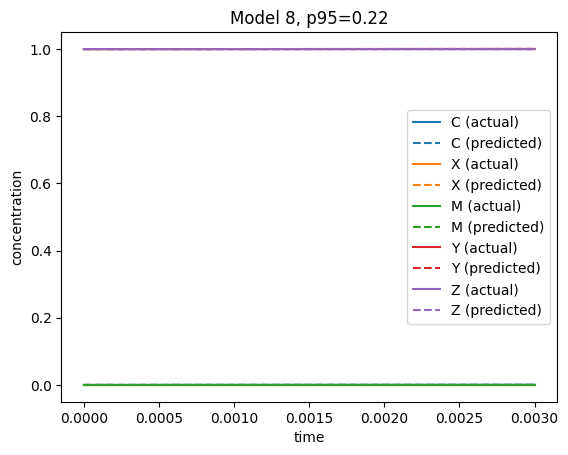

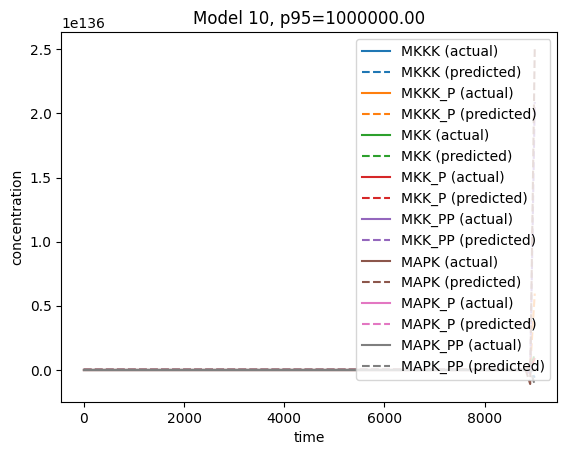

In [3]:
iterator = BiomodelsIterator(
            is_report=True,
            #excluded_models=excluded_models,
            first_model_num=1,
            last_model_num=10)
for item in iterator:
    if item.model_num in [11, 12, 14, 19]:
        print(f"Excluding model {item.model_num}")
        continue
    try:
        plotModel(item.model_num)
    except:
        print(f"Failed on model {item.model_num}")
    

# Splitting

In [4]:
def evaluateMlp(model_num, num_splits=2, **kwargs):
    if not isinstance(num_splits, list):
        num_splits = [num_splits]
    trajectory = Trajectory.makeBiomodel(model_num=model_num, end_time=10)
    tcs = [TrajectoryCollection.autoSplit(trajectory, num_split=n) for n in num_splits]
    #
    lp = LinearPredictor(trajectory)
    lp.plotPrediction(**kwargs)
    #
    for tc in tcs:
        mlp = MultipleLinearPredictor(tc)
        mlp.plotPrediction(**kwargs)

In [5]:
#evaluateMlp(599, num_split=1, legend=False)

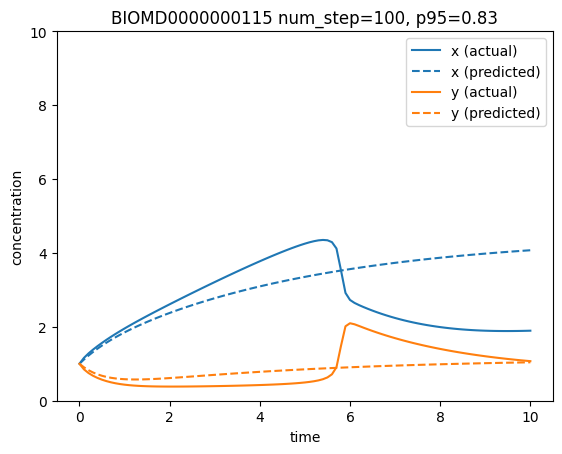

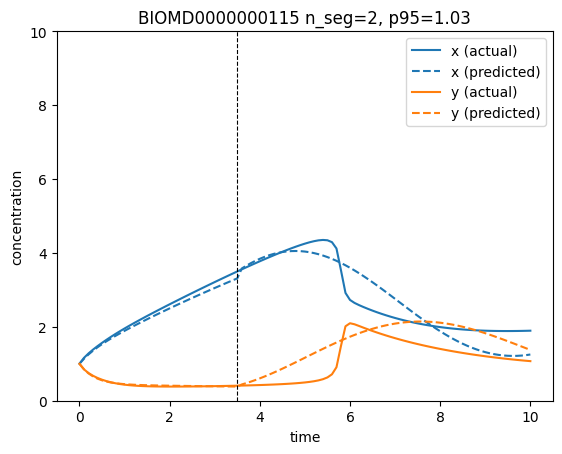

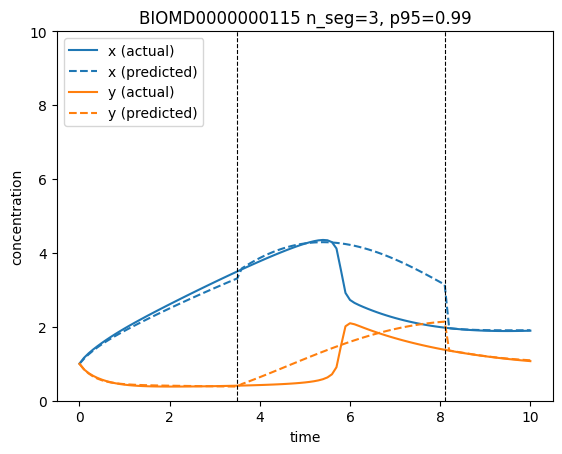

In [6]:
evaluateMlp(115, num_splits=[1, 2], ylim=[0, 10], legend=True)

Cannot use JAC_FITTED: num_species (3) > num_point (2).
Cannot use JAC_FITTED: num_species (3) > num_point (2).
Cannot use JAC_FITTED: num_species (3) > num_point (2).
Cannot use JAC_FITTED: num_species (3) > num_point (2).


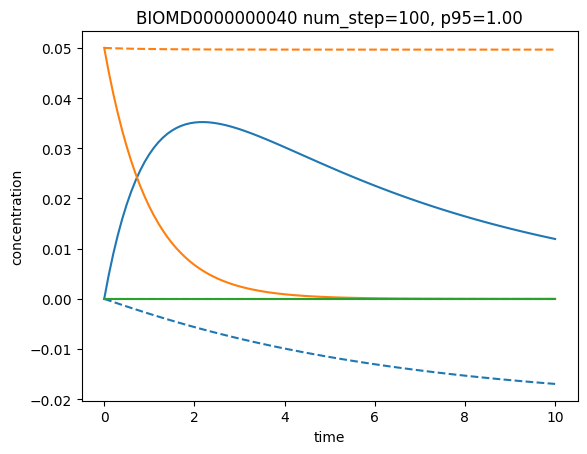

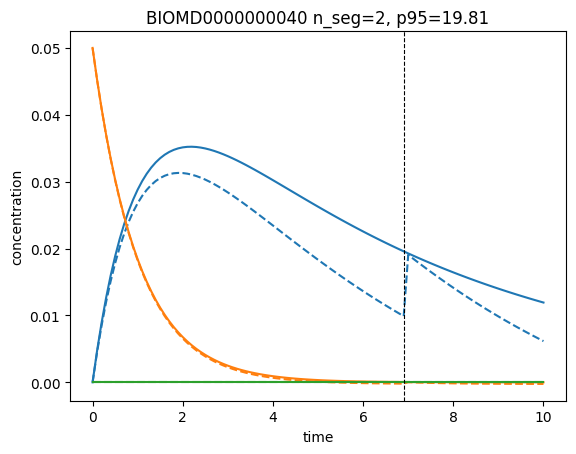

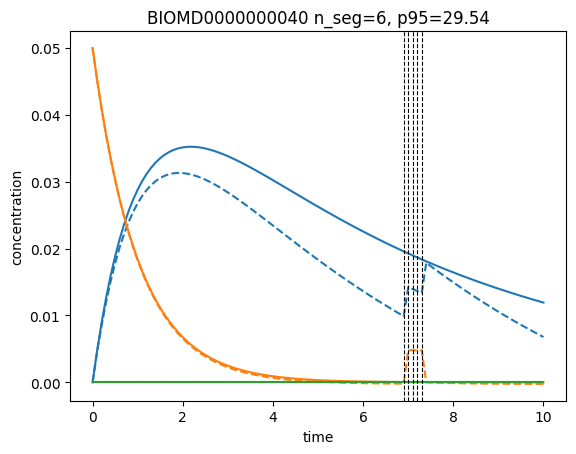

In [10]:
evaluateMlp(40, num_splits=[1,5],legend=False)

# Histograms

## Aggregate Data

In [ ]:
ffiles = [f for f in os.listdir(cn.DATA_DIR) if "linear_predictor_score" in f]
dfs = []
for ffile in ffiles:
    df = pd.read_csv(os.path.join(cn.DATA_DIR, ffile))
    dfs.append(df)
merged_df = pd.concat(dfs)
ALL_DF = merged_df.reset_index()
ALL_PATH = "all_data.csv"
ALL_DF.to_csv(ALL_PATH)

In [ ]:
MODEL_DF = ALL_DF[ALL_DF["aggregation_type"] == "model"]
p95_arr = np.sort(MODEL_DF["p95"].values)
count = len(p95_arr)
_, ax = plt.subplots()
ax.plot(p95_arr, np.array(range(count))/count)
ax.set_xlim(0, 1)
ax.set_title(f"RAE 95th Percentile for {len(MODEL_DF)} Models")

In [ ]:
SPECIES_DF = ALL_DF[ALL_DF["aggregation_type"] != "model"]
p95_arr = np.sort(SPECIES_DF["p95"].values)
count = len(p95_arr)
_, ax = plt.subplots()
ax.plot(p95_arr, np.array(range(count))/count)
ax.set_xlim(0, 1)
ax.set_title(f"RAE 95th Percentile for {len(SPECIES_DF)} Species")